# End-to-End Fine-tuning: PhoBERT + TF-IDF Hybrid

## Kiến trúc:
```
Text → PhoBERT (UNFROZEN, fine-tuned) → 768-dim embedding
                                    ↘
                                      Concatenate → 5768-dim → Classifier → 3 classes
                                    ↗
Text → TF-IDF (5000 features) → 5000-dim
```

## Cải tiến:
1. **PhoBERT UNFROZEN** - Fine-tune end-to-end
2. **TF-IDF 5000 features** - Hybrid với traditional features
3. **SMOTE** - Xử lý class imbalance
4. **Class Weights** - CrossEntropyLoss với weighted loss

## 1. Setup và Import Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers torch scikit-learn matplotlib seaborn imbalanced-learn underthesea tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.3 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import pickle
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

## 2. Configuration

In [5]:
class Config:
    BASE_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis'
    DATA_DIR = f'{BASE_DIR}/data/processed'
    MODEL_TYPE = 'PhoBERT_TF-IDF_E2E'  # End-to-End
    EXPERIMENT_TYPE = 'improvements'
    TIMESTAMP = '20260316'
    RESULTS_DIR = f'{BASE_DIR}/results/{MODEL_TYPE}/{EXPERIMENT_TYPE}/{TIMESTAMP}'

    MODEL_NAME = 'vinai/phobert-base'
    MAX_LENGTH = 256
    BATCH_SIZE = 16  # Smaller for fine-tuning
    NUM_CLASSES = 3

    # TF-IDF Config
    TFIDF_MAX_FEATURES = 5000
    TFIDF_NGRAM_RANGE = (1, 2)

    # Training Config
    LEARNING_RATE = 2e-5
    EPOCHS = 5  # Reduced from 10
    WARMUP_RATIO = 0.1
    EARLY_STOP_PATIENCE = 2  # Reduced from 3

    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # SMOTE Config
    USE_SMOTE = True
    SMOTE_SAMPLING_STRATEGY = {0: 5325, 1: 3000, 2: 5643}

    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

config = Config()
for dir_path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR,
                 config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

print('='*60)
print('END-TO-END FINE-TUNING CONFIGURATION')
print('='*60)
print(f'Model: {config.MODEL_NAME}')
print(f'TF-IDF Features: {config.TFIDF_MAX_FEATURES}')
print(f'Learning Rate: {config.LEARNING_RATE}')
print(f'Batch Size: {config.BATCH_SIZE}')
print(f'Epochs: {config.EPOCHS}')
print(f'Use SMOTE: {config.USE_SMOTE}')
print(f'Device: {config.DEVICE}')
print(f'Results Dir: {config.RESULTS_DIR}')

END-TO-END FINE-TUNING CONFIGURATION
Model: vinai/phobert-base
TF-IDF Features: 5000
Learning Rate: 2e-05
Batch Size: 16
Epochs: 5
Use SMOTE: True
Device: cuda
Results Dir: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF_E2E/improvements/20260316


## 3. Load Data

In [6]:
import sys
sys.path.append(config.BASE_DIR)
from src.data_utils import load_data

train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

print(f'Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}')

Train: 11426, Val: 1583, Test: 3166


In [7]:
print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}:')
    for label, count in sorted(counter.items()):
        print(f'  {config.LABEL_MAP[label]}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train:
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Val:
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test:
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. TF-IDF Feature Extraction

In [8]:
from src.data_utils import preprocess_vietnamese

train_texts_processed = [preprocess_vietnamese(t) for t in train_texts]
val_texts_processed = [preprocess_vietnamese(t) for t in val_texts]
test_texts_processed = [preprocess_vietnamese(t) for t in test_texts]

print('Creating TF-IDF vectorizer...')
tfidf_vectorizer = TfidfVectorizer(
    max_features=config.TFIDF_MAX_FEATURES,
    ngram_range=config.TFIDF_NGRAM_RANGE,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

train_tfidf = tfidf_vectorizer.fit_transform(train_texts_processed)
val_tfidf = tfidf_vectorizer.transform(val_texts_processed)
test_tfidf = tfidf_vectorizer.transform(test_texts_processed)

print(f'TF-IDF shapes: Train={train_tfidf.shape}, Val={val_tfidf.shape}, Test={test_tfidf.shape}')

# Save vectorizer
with open(os.path.join(config.ARTIFACTS_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print('TF-IDF vectorizer saved!')

Creating TF-IDF vectorizer...
TF-IDF shapes: Train=(11426, 5000), Val=(1583, 5000), Test=(3166, 5000)
TF-IDF vectorizer saved!


## 5. Dataset & Model Definition

In [9]:
class HybridDataset(Dataset):
    """Dataset for hybrid PhoBERT + TF-IDF features"""
    def __init__(self, texts, tfidf_features, labels, tokenizer, max_length):
        self.texts = texts
        self.tfidf_features = tfidf_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        tfidf = self.tfidf_features[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'tfidf': torch.tensor(tfidf, dtype=torch.float),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [10]:
class PhoBERTTFIDFHybrid(nn.Module):
    """Hybrid model: PhoBERT (fine-tuned) + TF-IDF features"""
    def __init__(self, model_name, tfidf_dim, num_classes, dropout=0.1):
        super(PhoBERTTFIDFHybrid, self).__init__()

        # PhoBERT encoder
        self.phobert = AutoModel.from_pretrained(model_name)
        phobert_dim = self.phobert.config.hidden_size  # 768

        # TF-IDF projection layer (optional: reduce dimension)
        self.tfidf_proj = nn.Sequential(
            nn.Linear(tfidf_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Combined classifier
        combined_dim = phobert_dim + 256  # 768 + 256 = 1024
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(combined_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, tfidf_features):
        # PhoBERT forward
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        phobert_emb = outputs.last_hidden_state[:, 0, :]  # [CLS] token

        # TF-IDF projection
        tfidf_proj = self.tfidf_proj(tfidf_features)

        # Concatenate
        combined = torch.cat([phobert_emb, tfidf_proj], dim=1)

        # Classification
        logits = self.classifier(combined)
        return logits

In [11]:
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print(f'Tokenizer loaded: {config.MODEL_NAME}')

model = PhoBERTTFIDFHybrid(
    model_name=config.MODEL_NAME,
    tfidf_dim=config.TFIDF_MAX_FEATURES,
    num_classes=config.NUM_CLASSES
)
model = model.to(config.DEVICE)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print('Model initialized!')

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: vinai/phobert-base


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 136,541,699
Trainable parameters: 136,541,699
Model initialized!


## 6. Apply SMOTE on TF-IDF Features

In [12]:
# Prepare TF-IDF as numpy arrays
train_tfidf_dense = train_tfidf.toarray()
val_tfidf_dense = val_tfidf.toarray()
test_tfidf_dense = test_tfidf.toarray()

if config.USE_SMOTE:
    print('='*60)
    print('APPLYING SMOTE')
    print('='*60)
    print('Before SMOTE:', Counter(train_labels))

    smote = SMOTE(
        sampling_strategy=config.SMOTE_SAMPLING_STRATEGY,
        random_state=42,
        k_neighbors=5
    )

    # Apply SMOTE on TF-IDF features (we'll use resampled indices)
    train_tfidf_resampled, train_labels_resampled = smote.fit_resample(train_tfidf_dense, train_labels)

    print('After SMOTE:', Counter(train_labels_resampled))

    # For texts, we need to resample manually
    # Get resampled indices
    from imblearn.over_sampling import SMOTE
    smote_indices = []
    original_len = len(train_texts)

    # Use SMOTE to get which samples are synthetic
    # We'll duplicate original texts for synthetic samples
    train_texts_resampled = list(train_texts)  # Start with original

    # Find synthetic samples (those beyond original length)
    n_synthetic = len(train_labels_resampled) - len(train_labels)
    print(f'Synthetic samples added: {n_synthetic}')

    # For synthetic samples, use nearest neighbor's text
    # Simple approach: duplicate texts based on label distribution
    label_to_indices = {0: [], 1: [], 2: []}
    for i, label in enumerate(train_labels):
        label_to_indices[label].append(i)

    # Count how many new samples per class
    original_counts = Counter(train_labels)
    new_counts = Counter(train_labels_resampled)

    for label in [0, 1, 2]:
        n_new = new_counts[label] - original_counts[label]
        if n_new > 0:
            # Randomly duplicate texts from this class
            indices = label_to_indices[label]
            for _ in range(n_new):
                idx = random.choice(indices)
                train_texts_resampled.append(train_texts[idx])

    print(f'Resampled texts: {len(train_texts_resampled)}')

    # Update training data
    train_texts_final = train_texts_resampled
    train_tfidf_final = train_tfidf_resampled
    train_labels_final = train_labels_resampled
else:
    train_texts_final = train_texts
    train_tfidf_final = train_tfidf_dense
    train_labels_final = np.array(train_labels)

print(f'Final training samples: {len(train_texts_final)}')

APPLYING SMOTE
Before SMOTE: Counter({2: 5643, 0: 5325, 1: 458})
After SMOTE: Counter({2: 5643, 0: 5325, 1: 3000})
Synthetic samples added: 2542
Resampled texts: 13968
Final training samples: 13968


## 7. Create DataLoaders

In [13]:
# Create datasets
train_dataset = HybridDataset(
    train_texts_final, train_tfidf_final, train_labels_final,
    tokenizer, config.MAX_LENGTH
)
val_dataset = HybridDataset(
    val_texts, val_tfidf_dense, val_labels,
    tokenizer, config.MAX_LENGTH
)
test_dataset = HybridDataset(
    test_texts, test_tfidf_dense, test_labels,
    tokenizer, config.MAX_LENGTH
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    test_dataset, batch_size=config.BATCH_SIZE, shuffle=False
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 873
Val batches: 99
Test batches: 198


## 8. Training Setup

In [14]:
# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_labels_final
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(config.DEVICE)
print(f'Class weights: {class_weights}')

# Optimizer with different learning rates
optimizer = torch.optim.AdamW([
    {'params': model.phobert.parameters(), 'lr': config.LEARNING_RATE},
    {'params': model.tfidf_proj.parameters(), 'lr': config.LEARNING_RATE * 10},
    {'params': model.classifier.parameters(), 'lr': config.LEARNING_RATE * 10}
])

# Scheduler
total_steps = len(train_loader) * config.EPOCHS
warmup_steps = int(total_steps * config.WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f'Total steps: {total_steps}')
print(f'Warmup steps: {warmup_steps}')

Class weights: tensor([0.8744, 1.5520, 0.8251], device='cuda:0')
Total steps: 4365
Warmup steps: 436


## 9. Training Loop

In [15]:
def train_epoch(model, dataloader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc='Training'):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        tfidf = batch['tfidf'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, tfidf)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        _, preds = torch.max(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(dataloader), correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            tfidf = batch['tfidf'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, tfidf)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            _, preds = torch.max(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(dataloader), correct / total, f1, all_preds, all_labels

In [16]:
print('='*60)
print('STARTING TRAINING')
print('='*60)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0
best_model_state = None
patience_counter = 0

for epoch in range(config.EPOCHS):
    print(f'\nEpoch {epoch + 1}/{config.EPOCHS}')
    print('-' * 40)

    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, config.DEVICE
    )

    # Validate
    val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(
        model, val_loader, criterion, config.DEVICE
    )

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}')

    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f'  -> New best model! F1: {best_val_f1:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= config.EARLY_STOP_PATIENCE:
            print(f'  -> Early stopping after {epoch + 1} epochs')
            break

print('\n' + '='*60)
print('TRAINING COMPLETED')
print('='*60)
print(f'Best Val F1: {best_val_f1:.4f}')

STARTING TRAINING

Epoch 1/5
----------------------------------------


Evaluating: 100%|██████████| 99/99 [00:21<00:00,  4.71it/s]


Train Loss: 0.5298, Train Acc: 0.7912
Val Loss: 0.2815, Val Acc: 0.9400, Val F1: 0.9390
  -> New best model! F1: 0.9390

Epoch 2/5
----------------------------------------


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.73it/s]


Train Loss: 0.1542, Train Acc: 0.9527
Val Loss: 0.3360, Val Acc: 0.9444, Val F1: 0.9443
  -> New best model! F1: 0.9443

Epoch 3/5
----------------------------------------


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.72it/s]


Train Loss: 0.0845, Train Acc: 0.9751
Val Loss: 0.4311, Val Acc: 0.9431, Val F1: 0.9421

Epoch 4/5
----------------------------------------


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.73it/s]

Train Loss: 0.0481, Train Acc: 0.9862
Val Loss: 0.4823, Val Acc: 0.9394, Val F1: 0.9385
  -> Early stopping after 4 epochs

TRAINING COMPLETED
Best Val F1: 0.9443


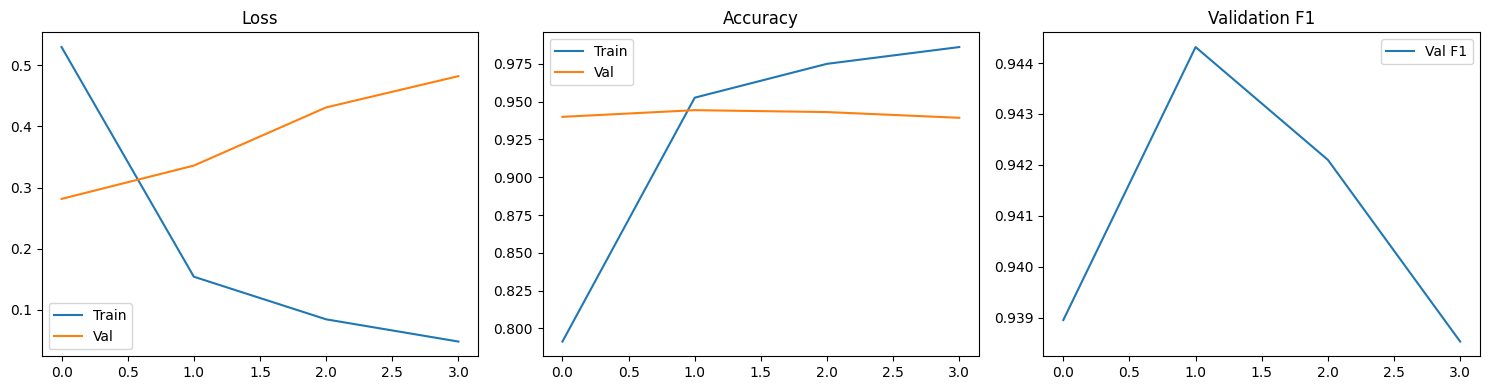

Training history saved!


In [17]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()

axes[2].plot(history['val_f1'], label='Val F1')
axes[2].set_title('Validation F1')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150)
plt.show()
print('Training history saved!')

## 10. Test Evaluation

In [18]:
# Load best model
model.load_state_dict(best_model_state)
model.eval()

# Evaluate on test set
test_loss, test_acc, test_f1, test_preds, test_labels_actual = evaluate(
    model, test_loader, criterion, config.DEVICE
)

print('='*60)
print('TEST RESULTS')
print('='*60)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1 (weighted): {test_f1:.4f}')

print('\nClassification Report:')
print(classification_report(
    test_labels_actual, test_preds,
    target_names=list(config.LABEL_MAP.values())
))

Evaluating: 100%|██████████| 198/198 [00:42<00:00,  4.70it/s]

TEST RESULTS
Test Accuracy: 0.9311
Test F1 (weighted): 0.9291

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95      1409
     Neutral       0.65      0.51      0.58       167
    Positive       0.95      0.95      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.85      0.81      0.82      3166
weighted avg       0.93      0.93      0.93      3166



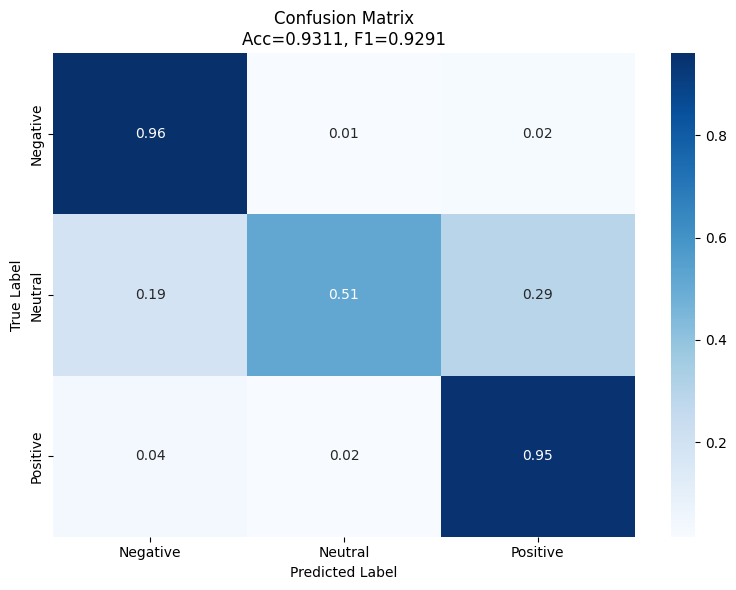

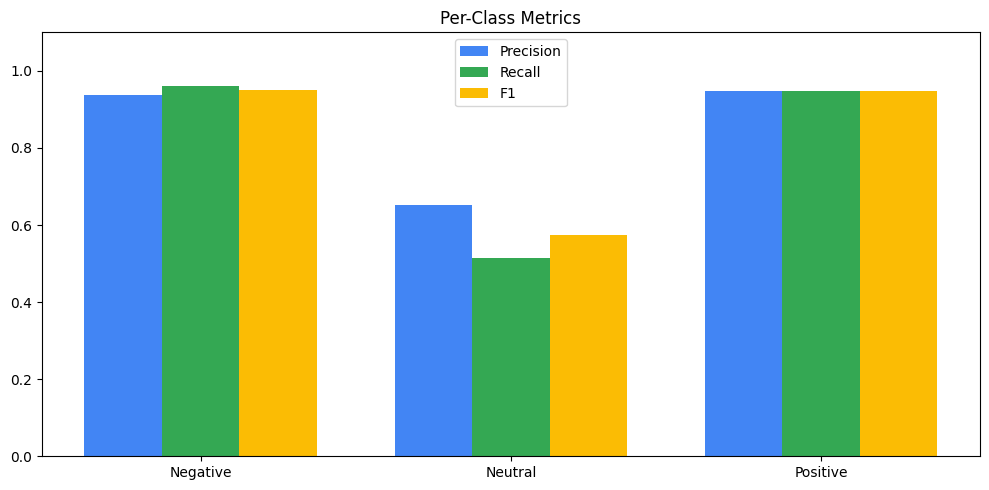

In [19]:
# Confusion matrix
cm = confusion_matrix(test_labels_actual, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()),
            cmap='Blues')
plt.title(f'Confusion Matrix\nAcc={test_acc:.4f}, F1={test_f1:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

# Per-class metrics
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1_per_class, _ = precision_recall_fscore_support(
    test_labels_actual, test_preds, labels=[0, 1, 2]
)

x = np.arange(3)
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, prec, width, label='Precision', color='#4285F4')
plt.bar(x, rec, width, label='Recall', color='#34A853')
plt.bar(x + width, f1_per_class, width, label='F1', color='#FBBC04')
plt.xticks(x, list(config.LABEL_MAP.values()))
plt.ylim(0, 1.1)
plt.title('Per-Class Metrics')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'per_class_metrics.png'), dpi=150)
plt.show()

## 11. Save Results

In [20]:
import json
from datetime import datetime

# Save model
torch.save(best_model_state, os.path.join(config.MODELS_DIR, 'phobert_tfidf_hybrid.pt'))
print('Model saved!')

# Save experiment summary
report = classification_report(
    test_labels_actual, test_preds,
    target_names=list(config.LABEL_MAP.values()),
    output_dict=True
)

summary = {
    'Model': 'PhoBERT_TF-IDF_E2E',
    'Accuracy': float(test_acc),
    'F1_weighted': float(test_f1),
    'Configuration': {
        'TFIDF_Max_Features': config.TFIDF_MAX_FEATURES,
        'Learning_Rate': config.LEARNING_RATE,
        'Batch_Size': config.BATCH_SIZE,
        'Epochs_Trained': len(history['train_loss']),
        'SMOTE': config.USE_SMOTE
    },
    'Per_Class_F1': {
        'Negative': report['Negative']['f1-score'],
        'Neutral': report['Neutral']['f1-score'],
        'Positive': report['Positive']['f1-score']
    }
}

with open(os.path.join(config.SUMMARIES_DIR, 'experiment_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

# Save training_results.txt
lines = [
    '=' * 50,
    'TRAINING RESULTS - PhoBERT + TF-IDF End-to-End',
    '=' * 50,
    f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    'Model Type: PhoBERT_TF-IDF_E2E',
    'Experiment: improvements/20260316',
    '',
    '-' * 50,
    'HYPERPARAMETERS',
    '-' * 50,
    f'Model: {config.MODEL_NAME}',
    f'TF-IDF Features: {config.TFIDF_MAX_FEATURES}',
    f'Learning Rate: {config.LEARNING_RATE}',
    f'Batch Size: {config.BATCH_SIZE}',
    f'SMOTE: {config.USE_SMOTE}',
    f'Class Weights: Yes',
    '',
    '-' * 50,
    'TEST RESULTS',
    '-' * 50,
    f'Test Accuracy: {test_acc:.4f}',
    f'Test F1 (weighted): {test_f1:.4f}',
    '',
    'Per-Class Metrics:',
    f'  Negative: P={report["Negative"]["precision"]:.4f}, R={report["Negative"]["recall"]:.4f}, F1={report["Negative"]["f1-score"]:.4f}',
    f'  Neutral:  P={report["Neutral"]["precision"]:.4f}, R={report["Neutral"]["recall"]:.4f}, F1={report["Neutral"]["f1-score"]:.4f}',
    f'  Positive: P={report["Positive"]["precision"]:.4f}, R={report["Positive"]["recall"]:.4f}, F1={report["Positive"]["f1-score"]:.4f}',
    '',
    '-' * 50,
    'TRAINING HISTORY',
    '-' * 50,
    f'Epochs trained: {len(history["train_loss"])}',
    f'Best Val F1: {best_val_f1:.4f}',
]

with open(os.path.join(config.SUMMARIES_DIR, 'training_results.txt'), 'w') as f:
    f.write('\n'.join(lines))

print('Results saved!')

Model saved!
Results saved!


## 12. Final Comparison

In [21]:
print('='*70)
print('FINAL COMPARISON - ALL EXPERIMENTS')
print('='*70)

print("""
| Model | Type | SMOTE | Accuracy | F1 | Neutral F1 |
|-------|------|-------|----------|-----|------------|
| PhoBERT Baseline | Fine-tuned | No | 0.9324 | 0.9307 | - |
| TF-IDF 5000 | Frozen + XGB | No | 0.9305 | 0.9296 | - |
| TF-IDF 3000 + SMOTE | Frozen + XGB | Yes | 0.9299 | 0.9292 | 0.5839 |
| TF-IDF 5000 + SMOTE | Frozen + XGB | Yes | 0.9311 | 0.9304 | 0.5938 |
| **THIS MODEL** | **E2E Fine-tuned** | **Yes** | **{:.4f}** | **{:.4f}** | **{:.4f}** |
""".format(test_acc, test_f1, report['Neutral']['f1-score']))

baseline_acc = 0.9324
if test_acc >= baseline_acc:
    print('\n*** NEW BEST RESULT! ***')
    print(f'Improved by: +{(test_acc - baseline_acc)*100:.2f}%')
else:
    print(f'\nNote: Below PhoBERT baseline by: -{(baseline_acc - test_acc)*100:.2f}%')
    print('But may have better Neutral class performance!')

FINAL COMPARISON - ALL EXPERIMENTS

| Model | Type | SMOTE | Accuracy | F1 | Neutral F1 |
|-------|------|-------|----------|-----|------------|
| PhoBERT Baseline | Fine-tuned | No | 0.9324 | 0.9307 | - |
| TF-IDF 5000 | Frozen + XGB | No | 0.9305 | 0.9296 | - |
| TF-IDF 3000 + SMOTE | Frozen + XGB | Yes | 0.9299 | 0.9292 | 0.5839 |
| TF-IDF 5000 + SMOTE | Frozen + XGB | Yes | 0.9311 | 0.9304 | 0.5938 |
| **THIS MODEL** | **E2E Fine-tuned** | **Yes** | **0.9311** | **0.9291** | **0.5753** |


Note: Below PhoBERT baseline by: -0.13%
But may have better Neutral class performance!
